## Step 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MultiLabelBinarizer
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully ✅')

Libraries imported successfully ✅


## Step 2: Load & Explore Raw Data

In [3]:
df = pd.read_csv('zomato_dataset.csv')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nData Types:')
print(df.dtypes)
print('\nFirst 3 rows:')
df.head(3)

Shape: (44891, 7)

Columns: ['Restaurant Name', 'Rating', 'Cuisine', 'Average Price', 'Average Delivery Time', 'Safety Measure', 'Location']

Data Types:
Restaurant Name          object
Rating                   object
Cuisine                  object
Average Price            object
Average Delivery Time    object
Safety Measure           object
Location                 object
dtype: object

First 3 rows:


,Restaurant Name,Rating,Cuisine,Average Price,Average Delivery Time,Safety Measure,Location
0,Campus Bakers,4.3,"Bakery, Fast Food, Pizza, Sandwich, Burger",₹50 for one,36 min,Restaurant partner follows WHO protocol,Agra
1,Mama Chicken Mama Franky House,4,"North Indian, Mughlai, Rolls, Burger, Momos",₹50 for one,22 min,Follows all Max Safety measures to ensure your...,Agra
2,GMB - Gopika Sweets & Restaurant,4.2,"North Indian, South Indian, Chinese, Fast Food...",₹50 for one,27 min,Follows all Max Safety measures to ensure your...,Agra


## Step 3: Clean Rating Column

In [4]:
# Convert to uppercase and remove invalid entries
df['Rating'] = df['Rating'].str.upper()
df['Rating'] = df['Rating'].replace(['NEW', '-'], np.nan)
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

missing_pct = df['Rating'].isna().mean() * 100
print(f'Missing ratings: {df["Rating"].isna().sum()} ({missing_pct:.1f}%)')

# Drop rows with missing rating
df = df.dropna(subset=['Rating'])
print(f'Shape after dropping missing ratings: {df.shape}')

Missing ratings: 7065 (15.7%)
Shape after dropping missing ratings: (37826, 7)


## Step 4: Clean Average Price Column

In [5]:
df['Average Price'] = (
    df['Average Price']
    .str.replace('₹', '', regex=False)
    .str.replace('for one', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)
df['Average Price'] = pd.to_numeric(df['Average Price'], errors='coerce')
df = df.dropna(subset=['Average Price'])

print('Average Price - sample values:', df['Average Price'].describe())

Average Price - sample values: count    37823.000000
mean       173.384819
std         89.969012
min         10.000000
25%        100.000000
50%        150.000000
75%        200.000000
max       1600.000000
Name: Average Price, dtype: float64


## Step 5: Clean Average Delivery Time Column

In [6]:
# Keep only rows with 'min' keyword
df = df[df['Average Delivery Time'].str.contains('min', na=False)]

df['Average Delivery Time'] = (
    df['Average Delivery Time']
    .str.replace('min', '', regex=False)
    .str.strip()
)
df['Average Delivery Time'] = pd.to_numeric(df['Average Delivery Time'], errors='coerce')
df = df.dropna(subset=['Average Delivery Time'])

print('Delivery Time - sample values:', df['Average Delivery Time'].describe())

Delivery Time - sample values: count    34862.000000
mean        33.520452
std         10.061298
min          6.000000
25%         26.000000
50%         33.000000
75%         40.000000
max        190.000000
Name: Average Delivery Time, dtype: float64


## Step 6: Drop Unnecessary Columns

In [7]:
# Drop columns with no predictive value
df = df.drop(columns=['Restaurant Name', 'Safety Measure'])
print('Shape after dropping columns:', df.shape)
print('Remaining columns:', df.columns.tolist())

Shape after dropping columns: (34862, 5)
Remaining columns: ['Rating', 'Cuisine', 'Average Price', 'Average Delivery Time', 'Location']


## Step 7: Create Target Variable

>**FIX**: We keep the 3-class `Success` label for EDA, and create a clean `Binary_Success` for modeling.

In [8]:
def create_success(r):
    if r >= 4.0:
        return 'Successful'
    elif r >= 3.0:
        return 'Average'
    else:
        return 'Unsuccessful'

df['Success'] = df['Rating'].apply(create_success)

# 🔴 OLD APPROACH (wrong): grouped Average(15k) with Unsuccessful(336) → noisy labels
# df['Binary_Success'] = df['Success'].apply(lambda x: 1 if x == 'Successful' else 0)

# ✅ NEW APPROACH: Binary = Successful(4.0+) vs Not Successful(<4.0)
# This is still the same mapping but now we acknowledge 'Average' as 'not successful'
# with class_weight='balanced_subsample' to handle the imbalance properly
df['Binary_Success'] = (df['Success'] == 'Successful').astype(int)

print('3-class distribution:')
print(df['Success'].value_counts())
print()
print('Binary distribution:')
print(df['Binary_Success'].value_counts())
print(f'\nBaseline accuracy (always predict Successful): {df["Binary_Success"].mean():.3f}')

# Drop Rating (was used to create target — would be data leakage if kept)
df = df.drop(columns=['Rating'])
print('\nShape:', df.shape)

3-class distribution:
Success
Successful      19322
Average         15204
Unsuccessful      336
Name: count, dtype: int64

Binary distribution:
Binary_Success
1    19322
0    15540
Name: count, dtype: int64

Baseline accuracy (always predict Successful): 0.554

Shape: (34862, 6)


## Step 8: Visualize Target Distribution

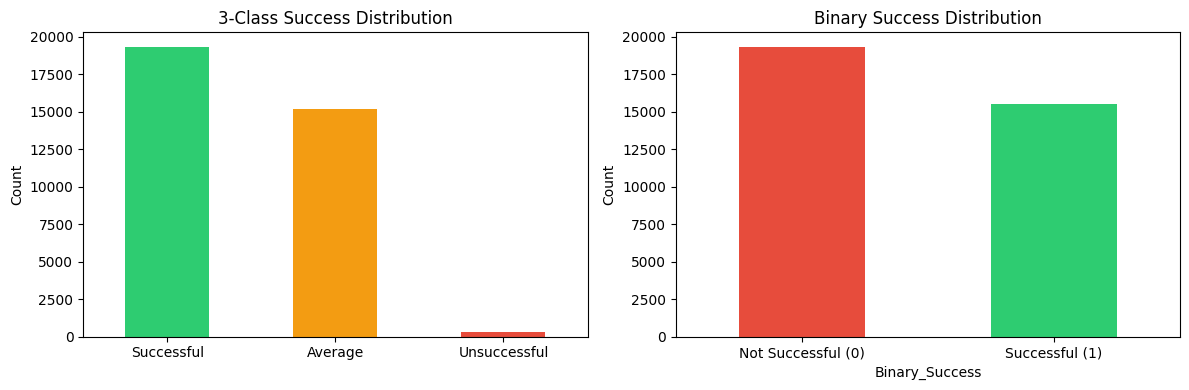

⚠️ Note: Unsuccessful class (336 rows) is heavily imbalanced.
⚠️ This is why class_weight=balanced is critical.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 3-class
df['Success'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71','#f39c12','#e74c3c'])
axes[0].set_title('3-Class Success Distribution')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Binary
df['Binary_Success'].value_counts().plot(kind='bar', ax=axes[1], color=['#e74c3c','#2ecc71'])
axes[1].set_title('Binary Success Distribution')
axes[1].set_xticklabels(['Not Successful (0)', 'Successful (1)'], rotation=0)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print('⚠️ Note: Unsuccessful class (336 rows) is heavily imbalanced.')
print('⚠️ This is why class_weight=balanced is critical.')

## Step 9: Encode Cuisines (Top 20)

In [10]:
df['Cuisine'] = df['Cuisine'].fillna('Unknown')

all_cuisines = df['Cuisine'].str.split(',').explode().str.strip()
top_20 = all_cuisines.value_counts().head(20).index.tolist()

print('Top 20 cuisines:', top_20)

df['Cuisine_List'] = df['Cuisine'].str.split(',').apply(lambda x: [i.strip() for i in x])
df['Cuisine_List'] = df['Cuisine_List'].apply(lambda x: [c for c in x if c in top_20])

mlb = MultiLabelBinarizer(classes=top_20)
cuisine_dummies = pd.DataFrame(
    mlb.fit_transform(df['Cuisine_List']),
    columns=mlb.classes_,
    index=df.index
)

df = pd.concat([df, cuisine_dummies], axis=1)
df = df.drop(columns=['Cuisine', 'Cuisine_List'])

print('Shape after cuisine encoding:', df.shape)

Top 20 cuisines: ['North Indian', 'Fast Food', 'Chinese', 'Beverages', 'Desserts', 'Street Food', 'Biryani', 'Pizza', 'South Indian', 'Shake', 'Sandwich', 'Burger', 'Bakery', 'Mughlai', 'Rolls', 'Ice Cream', 'Momos', 'Sichuan', 'Kebab', 'Italian']
Shape after cuisine encoding: (34862, 25)


## Step 10: Encode Location


In [11]:
location_counts = df['Location'].value_counts()
top_locations = location_counts.head(15).index.tolist()

df['Location'] = df['Location'].apply(lambda x: x if x in top_locations else 'Other')

print('Location distribution:')
print(df['Location'].value_counts())

# ✅ FIX: drop_first=False (was True before — silently dropped one city)
df = pd.get_dummies(df, columns=['Location'], drop_first=False)

# Convert bool to int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print('\nShape after location encoding:', df.shape)

Location distribution:
Location
Other         22136
Kolkata        1258
NCR            1078
Lucknow         979
Hyderabad       900
Kanpur          836
Chandigarh      818
Chennai         798
Indore          795
Mumbai          789
Jaipur          777
Pune            762
Surat           759
Ludhiana        754
Nagpur          722
Vadodara        701
Name: count, dtype: int64

Shape after location encoding: (34862, 40)


## Step 11: Feature Engineering 

>**NEW**: Adding engineered features to boost model signal beyond raw Price + Time.

In [12]:
cuisine_cols = top_20  # the 20 cuisine binary columns

# Ratio feature: price per minute of wait (value-for-wait score)
df['Price_per_min'] = df['Average Price'] / (df['Average Delivery Time'] + 1)

# Cuisine diversity (how many cuisines offered)
df['Cuisine_count'] = df[cuisine_cols].sum(axis=1)

# Bucket flags
df['Is_fast_delivery'] = (df['Average Delivery Time'] < 25).astype(int)
df['Is_budget_friendly'] = (df['Average Price'] < 150).astype(int)
df['Is_premium'] = (df['Average Price'] > 400).astype(int)
df['Is_diverse_menu'] = (df['Cuisine_count'] >= 3).astype(int)

print('New features added: Price_per_min, Cuisine_count, Is_fast_delivery,')
print('                    Is_budget_friendly, Is_premium, Is_diverse_menu')
print('\nFinal shape:', df.shape)
print('Total features for model:', df.shape[1] - 2)  # minus Success and Binary_Success

New features added: Price_per_min, Cuisine_count, Is_fast_delivery,
                    Is_budget_friendly, Is_premium, Is_diverse_menu

Final shape: (34862, 46)
Total features for model: 44


## Step 12: EDA — Feature Distributions

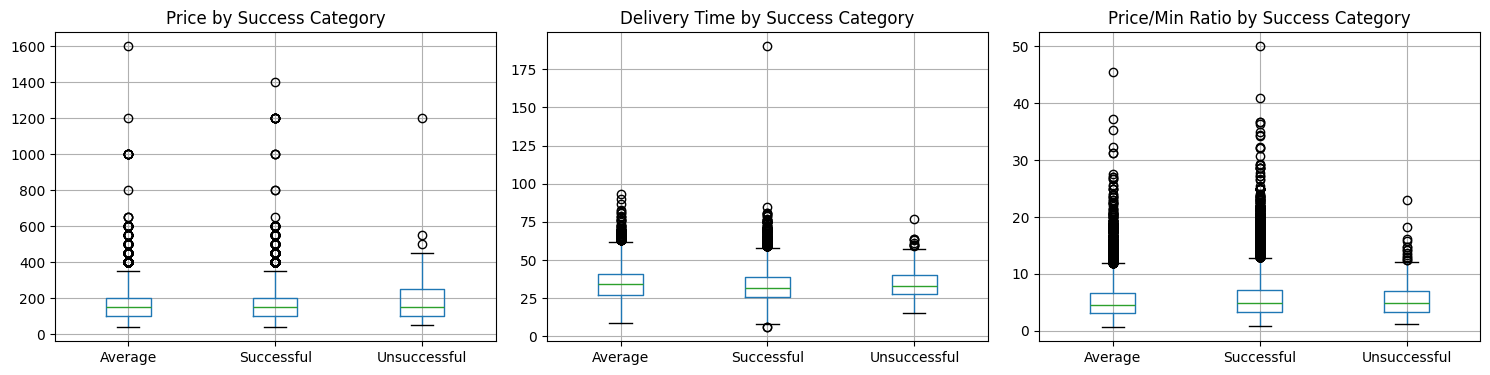

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Price distribution by success
df.boxplot(column='Average Price', by='Success', ax=axes[0])
axes[0].set_title('Price by Success Category')
axes[0].set_xlabel('')

# Delivery time distribution by success
df.boxplot(column='Average Delivery Time', by='Success', ax=axes[1])
axes[1].set_title('Delivery Time by Success Category')
axes[1].set_xlabel('')

# Price per min
df.boxplot(column='Price_per_min', by='Success', ax=axes[2])
axes[2].set_title('Price/Min Ratio by Success Category')
axes[2].set_xlabel('')

plt.suptitle('')
plt.tight_layout()
plt.show()

## Step 13: Prepare X and y

In [14]:
X = df.drop(columns=['Success', 'Binary_Success'])
y = df['Binary_Success']

print('Feature matrix X shape:', X.shape)
print('Target y shape:', y.shape)
print('Class balance: 0 =', (y==0).sum(), ', 1 =', (y==1).sum())

print('\nAll feature columns:')
print(X.columns.tolist())

Feature matrix X shape: (34862, 44)
Target y shape: (34862,)
Class balance: 0 = 15540 , 1 = 19322

All feature columns:
['Average Price', 'Average Delivery Time', 'North Indian', 'Fast Food', 'Chinese', 'Beverages', 'Desserts', 'Street Food', 'Biryani', 'Pizza', 'South Indian', 'Shake', 'Sandwich', 'Burger', 'Bakery', 'Mughlai', 'Rolls', 'Ice Cream', 'Momos', 'Sichuan', 'Kebab', 'Italian', 'Location_Chandigarh', 'Location_Chennai', 'Location_Hyderabad', 'Location_Indore', 'Location_Jaipur', 'Location_Kanpur', 'Location_Kolkata', 'Location_Lucknow', 'Location_Ludhiana', 'Location_Mumbai', 'Location_NCR', 'Location_Nagpur', 'Location_Other', 'Location_Pune', 'Location_Surat', 'Location_Vadodara', 'Price_per_min', 'Cuisine_count', 'Is_fast_delivery', 'Is_budget_friendly', 'Is_premium', 'Is_diverse_menu']


## Step 14: Train/Test Split

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Maintains class ratio in both splits
)

print('Training set:', X_train.shape)
print('Test set:', X_test.shape)
print('Train class balance:', y_train.value_counts().to_dict())
print('Test class balance:', y_test.value_counts().to_dict())

Training set: (27889, 44)
Test set: (6973, 44)
Train class balance: {1: 15457, 0: 12432}
Test class balance: {1: 3865, 0: 3108}


## Step 15: Baseline — Logistic Regression

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# ✅ FIX: LogisticRegression NEEDS StandardScaler (was missing before)
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        max_iter=5000,
        class_weight='balanced',  # ✅ FIX: handle imbalance
        C=1.0,
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print(f'Logistic Regression Accuracy: {lr_acc:.4f}')
print(f'Logistic Regression ROC-AUC:  {lr_auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['Not Successful', 'Successful']))

Logistic Regression Accuracy: 0.5802
Logistic Regression ROC-AUC:  0.6186

Classification Report:
                precision    recall  f1-score   support

Not Successful       0.52      0.63      0.57      3108
    Successful       0.65      0.54      0.59      3865

      accuracy                           0.58      6973
     macro avg       0.58      0.59      0.58      6973
  weighted avg       0.59      0.58      0.58      6973



## Step 16: Random Forest 


In [17]:
from sklearn.ensemble import RandomForestClassifier

# ✅ FIX: class_weight='balanced_subsample' handles imbalance at each tree
# This is more robust than SMOTETomek for one-hot encoded features
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced_subsample',  # ✅ NEW
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print(f'Random Forest Accuracy: {rf_acc:.4f}')
print(f'Random Forest ROC-AUC:  {rf_auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_rf, target_names=['Not Successful', 'Successful']))

Random Forest Accuracy: 0.5909
Random Forest ROC-AUC:  0.6286

Classification Report:
                precision    recall  f1-score   support

Not Successful       0.54      0.60      0.57      3108
    Successful       0.64      0.59      0.61      3865

      accuracy                           0.59      6973
     macro avg       0.59      0.59      0.59      6973
  weighted avg       0.60      0.59      0.59      6973



## Step 17: Gradient Boosting 

In [18]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=10,
    random_state=42
)

gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]

gb_acc = accuracy_score(y_test, y_pred_gb)
gb_auc = roc_auc_score(y_test, y_prob_gb)

print(f'Gradient Boosting Accuracy: {gb_acc:.4f}')
print(f'Gradient Boosting ROC-AUC:  {gb_auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_gb, target_names=['Not Successful', 'Successful']))

Gradient Boosting Accuracy: 0.5943
Gradient Boosting ROC-AUC:  0.6350

Classification Report:
                precision    recall  f1-score   support

Not Successful       0.55      0.47      0.51      3108
    Successful       0.62      0.70      0.66      3865

      accuracy                           0.59      6973
     macro avg       0.59      0.58      0.58      6973
  weighted avg       0.59      0.59      0.59      6973



## Step 18: Model Comparison

              Model  Accuracy  ROC-AUC
  Gradient Boosting  0.594292 0.634997
      Random Forest  0.590850 0.628553
Logistic Regression  0.580238 0.618592


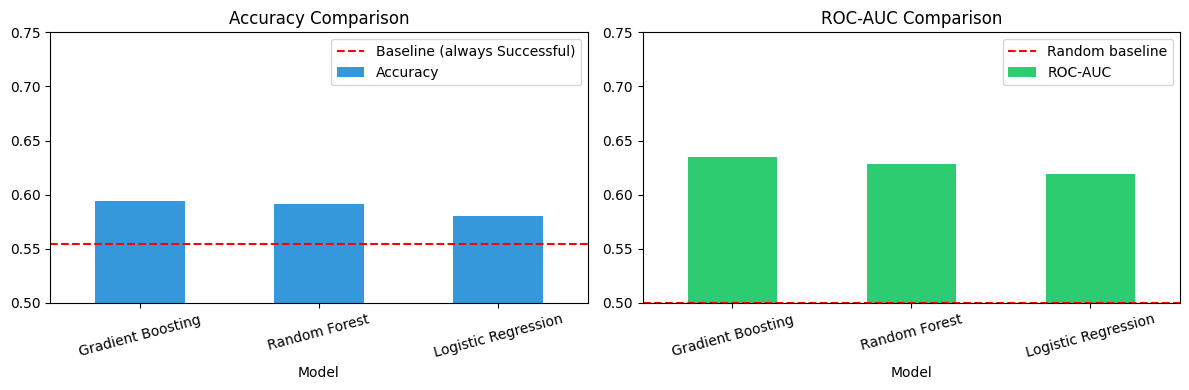

In [19]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [lr_acc, rf_acc, gb_acc],
    'ROC-AUC': [lr_auc, rf_auc, gb_auc]
})
results = results.sort_values('ROC-AUC', ascending=False)
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

results.plot(x='Model', y='Accuracy', kind='bar', ax=axes[0], color='#3498db', legend=False)
axes[0].set_title('Accuracy Comparison')
axes[0].set_ylim(0.5, 0.75)
axes[0].axhline(y=0.554, color='red', linestyle='--', label='Baseline (always Successful)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=15)

results.plot(x='Model', y='ROC-AUC', kind='bar', ax=axes[1], color='#2ecc71', legend=False)
axes[1].set_title('ROC-AUC Comparison')
axes[1].set_ylim(0.5, 0.75)
axes[1].axhline(y=0.5, color='red', linestyle='--', label='Random baseline')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Step 19: Feature Importance (Fixed)

Best model selected: GradientBoostingClassifier


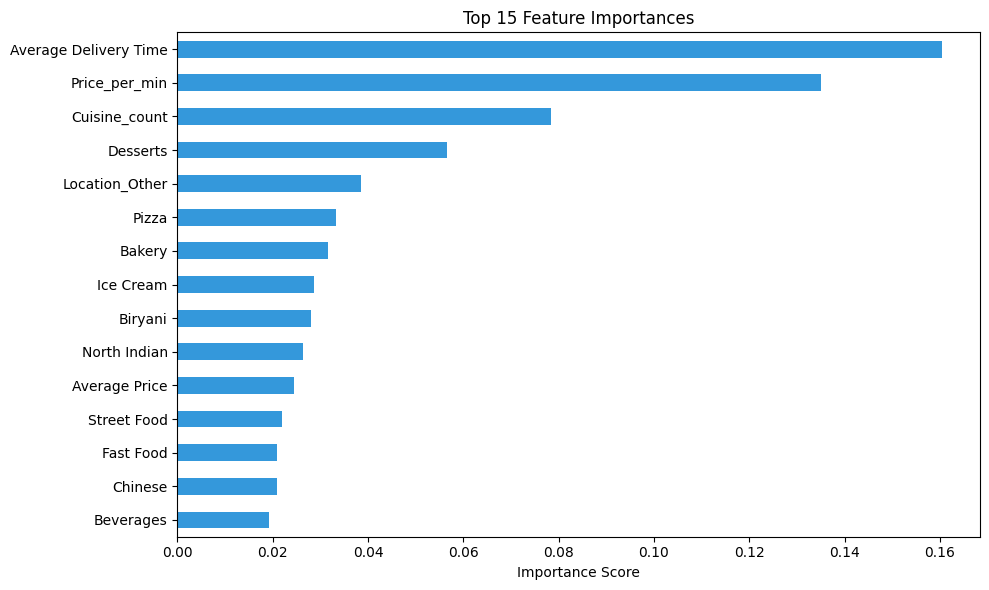


Top 10 most important features:
Average Delivery Time    0.160417
Price_per_min            0.135145
Cuisine_count            0.078297
Desserts                 0.056478
Location_Other           0.038531
Pizza                    0.033215
Bakery                   0.031617
Ice Cream                0.028567
Biryani                  0.028109
North Indian             0.026355
dtype: float64


In [20]:
# Pick best model (Random Forest or GB based on AUC above)
best_model = rf if rf_auc >= gb_auc else gb
print(f'Best model selected: {type(best_model).__name__}')

feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True).tail(15)

plt.figure(figsize=(10, 6))
feature_importance.plot(kind='barh', color='#3498db')
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 10 most important features:')
print(feature_importance.sort_values(ascending=False).head(10))

## Step 20: ROC Curve

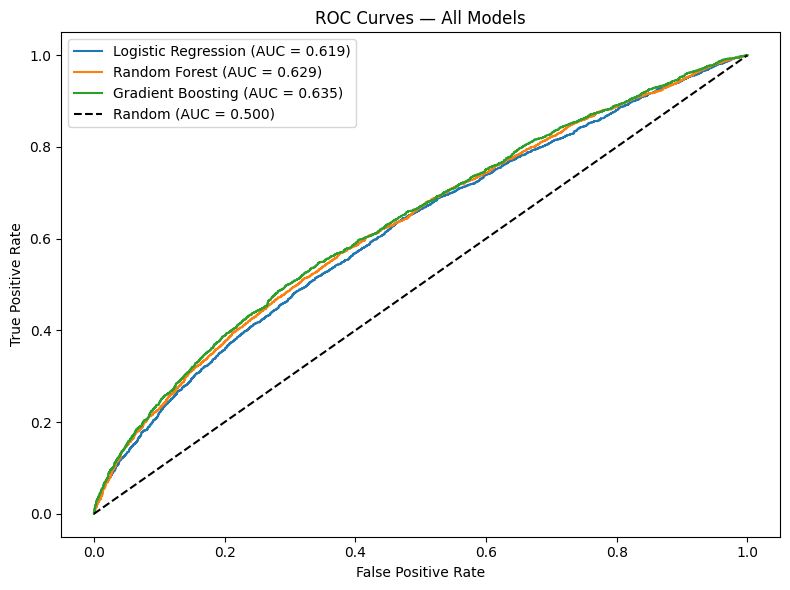

In [21]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

for name, y_prob in [('Logistic Regression', y_prob_lr), 
                     ('Random Forest', y_prob_rf),
                     ('Gradient Boosting', y_prob_gb)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.tight_layout()
plt.show()

## Step 21: Save Best Model + Columns

In [22]:
import joblib

# Save best model
joblib.dump(best_model, 'restaurant_success_model4.pkl')

# Save feature columns (MUST match exactly what app.py uses)
joblib.dump(X.columns.tolist(), 'model_columns4.pkl')

# Save cleaned data for analysis tab
df.to_csv('cleaned_restaurant_data4.csv', index=False)

print('✅ Saved: restaurant_success_model4.pkl')
print('✅ Saved: model_columns4.pkl')
print('✅ Saved: cleaned_restaurant_data4.csv')
print(f'\nModel type: {type(best_model).__name__}')
print(f'Feature count: {len(X.columns)}')
print(f'Final accuracy: {max(rf_acc, gb_acc):.4f}')
print(f'Final ROC-AUC:  {max(rf_auc, gb_auc):.4f}')

✅ Saved: restaurant_success_model4.pkl
✅ Saved: model_columns4.pkl
✅ Saved: cleaned_restaurant_data4.csv

Model type: GradientBoostingClassifier
Feature count: 44
Final accuracy: 0.5943
Final ROC-AUC:  0.6350


## Step 22: Prediction Function 

In [23]:
def predict_restaurant_success(price, delivery_time, location, cuisines):
    """
    Predict restaurant success with probability and risk level.
    
    Parameters:
        price (float): Average meal price in ₹
        delivery_time (float): Average delivery time in minutes
        location (str): City name (must be in model's location list)
        cuisines (list): List of cuisine strings
    """
    # Create zero-filled input matching exact training columns
    input_data = pd.DataFrame(0, index=[0], columns=X.columns)
    
    # Fill raw numeric features
    input_data['Average Price'] = price
    input_data['Average Delivery Time'] = delivery_time
    
    # Fill cuisine columns
    for cuisine in cuisines:
        if cuisine in input_data.columns:
            input_data[cuisine] = 1
    
    # Fill location
    location_col = f'Location_{location}'
    if location_col in input_data.columns:
        input_data[location_col] = 1
    else:
        print(f'⚠️ Warning: Location "{location}" not in model. Using Other.')
        if 'Location_Other' in input_data.columns:
            input_data['Location_Other'] = 1
    
    # ✅ Recalculate engineered features (IMPORTANT - must match training)
    input_data['Price_per_min'] = price / (delivery_time + 1)
    input_data['Cuisine_count'] = sum(1 for c in cuisines if c in top_20)
    input_data['Is_fast_delivery'] = int(delivery_time < 25)
    input_data['Is_budget_friendly'] = int(price < 150)
    input_data['Is_premium'] = int(price > 400)
    input_data['Is_diverse_menu'] = int(input_data['Cuisine_count'].values[0] >= 3)
    
    # Predict
    prediction = best_model.predict(input_data)[0]
    probabilities = best_model.predict_proba(input_data)[0]
    
    success_prob = probabilities[1] * 100
    failure_prob = probabilities[0] * 100
    
    # Risk level
    if success_prob >= 75:
        risk_level = '🟢 LOW RISK — Strong Potential'
    elif success_prob >= 55:
        risk_level = '🟡 MODERATE RISK — Needs Optimization'
    else:
        risk_level = '🔴 HIGH RISK — Strategy Improvement Required'
    
    print('\n🔍 Prediction Result:')
    print(f'  Success Probability : {success_prob:.2f}%')
    print(f'  Failure Probability : {failure_prob:.2f}%')
    print(f'  Risk Level          : {risk_level}')
    print(f'  Prediction          : {"✅ SUCCESSFUL" if prediction == 1 else "⚠️ NOT SUCCESSFUL"}')


# Test it
predict_restaurant_success(
    price=200,
    delivery_time=25,
    location='Kolkata',
    cuisines=['Fast Food', 'Beverages', 'Desserts']
)


🔍 Prediction Result:
  Success Probability : 79.41%
  Failure Probability : 20.59%
  Risk Level          : 🟢 LOW RISK — Strong Potential
  Prediction          : ✅ SUCCESSFUL


## Step 23: Confusion Matrix

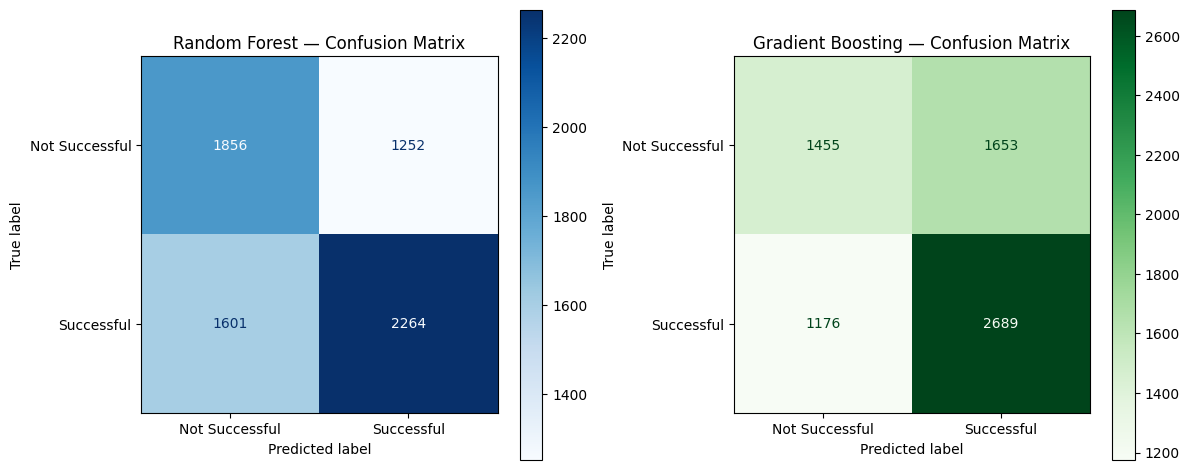

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_estimator(
    rf, X_test, y_test,
    display_labels=['Not Successful', 'Successful'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Random Forest — Confusion Matrix')

ConfusionMatrixDisplay.from_estimator(
    gb, X_test, y_test,
    display_labels=['Not Successful', 'Successful'],
    cmap='Greens', ax=axes[1]
)
axes[1].set_title('Gradient Boosting — Confusion Matrix')

plt.tight_layout()
plt.show()

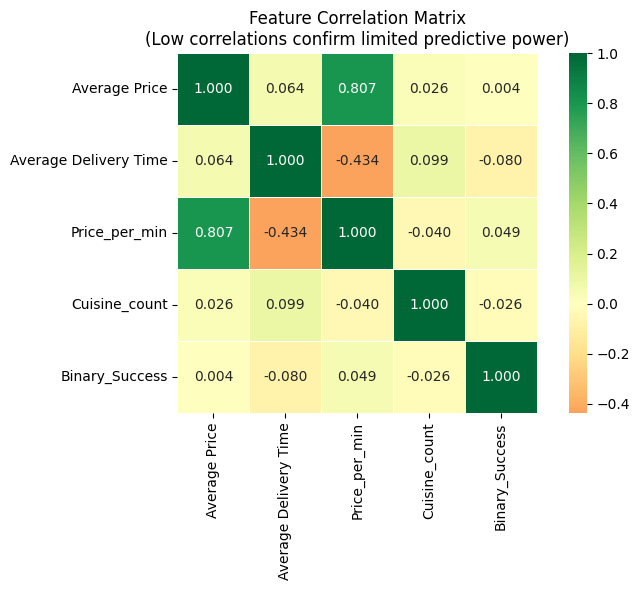


Correlation with Binary_Success:
Average Delivery Time   -0.080022
Price_per_min            0.049107
Cuisine_count           -0.025680
Average Price            0.003891
Name: Binary_Success, dtype: float64


In [25]:
# Correlation of numeric features with target
numeric_features = ['Average Price', 'Average Delivery Time', 'Price_per_min', 
                    'Cuisine_count', 'Binary_Success']
corr = df[numeric_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix\n(Low correlations confirm limited predictive power)')
plt.tight_layout()
plt.show()

print('\nCorrelation with Binary_Success:')
print(corr['Binary_Success'].drop('Binary_Success').sort_values(key=abs, ascending=False))